# 에듀테크 경쟁사 유튜브 벤치마킹 — 탐색적 분석

193개 경쟁사 채널의 수집 데이터를 탐색하고, 우리 채널의 위치를 진단합니다.

**실행 전 확인**
- 아직 데이터가 없다면 터미널에서 `python -m ytbench demo` 를 먼저 실행하세요
  (API 키 없이 모의 데이터로 전 과정이 돌아갑니다).
- 실데이터를 쓰려면 `python -m ytbench resolve && python -m ytbench collect && python -m ytbench analyze` 순서로 실행합니다.

> **이 노트북에 저장된 출력은 `demo` 모의 데이터(193채널 / 약 1만 영상)로 실행한 결과입니다.** 차트와 표의 *구조*를 미리 보기 위한 것이며, 수치 자체는 의미가 없습니다. 실데이터를 수집한 뒤 전체 셀을 다시 실행하세요.

## 1. 설정

In [1]:
import sys, warnings
from pathlib import Path

# 저장소 루트를 import 경로에 추가 (노트북은 notebooks/ 안에 있음)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ytbench import collect, config, features, llm, report, score, viz

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# 한글 폰트 + 차트 스타일 적용. 폰트를 못 찾으면 경고가 출력됩니다.
viz.apply_style()
print("준비 완료 —", ROOT)

준비 완료 — /home/user/Study/edutech_youtube_benchmark


## 2. 데이터 로드

`analyze` 단계의 산출물을 읽습니다. 파일이 없으면 원본 JSONL에서 즉석 계산합니다.

In [2]:
if config.SCORES_CSV.exists():
    video_features = pd.read_csv(config.VIDEO_FEATURES_CSV, encoding="utf-8-sig")
    channel_metrics = pd.read_csv(config.CHANNEL_METRICS_CSV, encoding="utf-8-sig")
    scores = pd.read_csv(config.SCORES_CSV, encoding="utf-8-sig")
    lift_path = config.PROCESSED / "pattern_lift.csv"
    lift = pd.read_csv(lift_path, encoding="utf-8-sig") if lift_path.exists() else pd.DataFrame()
    print("저장된 분석 결과를 불러왔습니다.")
else:
    print("분석 결과가 없어 원본에서 즉석 계산합니다...")
    videos_raw = collect.videos_to_frame()
    if videos_raw.empty:
        raise SystemExit("수집 데이터가 없습니다. 먼저 `python -m ytbench demo` 를 실행하세요.")
    video_features = features.build_video_features(videos_raw)
    channel_metrics = features.build_channel_metrics(collect.channels_to_frame(), video_features)
    lift = score.learn_success_patterns(video_features)
    scores = score.build_scores(channel_metrics, lift)

# published_kst 는 CSV 왕복 시 문자열이 되므로 되돌린다
if "published_kst" in video_features.columns:
    video_features["published_kst"] = pd.to_datetime(
        video_features["published_kst"], errors="coerce", utc=True
    ).dt.tz_convert(config.KST)

print(f"채널 {len(scores):,}개 · 영상 {len(video_features):,}개 · 검증 패턴 {len(lift)}개")

저장된 분석 결과를 불러왔습니다.
채널 193개 · 영상 10,282개 · 검증 패턴 13개


## 3. 데이터 품질 점검

**분석보다 이 단계가 먼저입니다.** 채널 매칭이 틀렸으면 모든 수치가 무의미해집니다.

In [3]:
checks = []

if config.RESOLVED_CSV.exists():
    resolved = pd.read_csv(config.RESOLVED_CSV, encoding="utf-8-sig")
    by_method = resolved["match_method"].value_counts()
    need_review = int(resolved["needs_review"].astype(str).str.lower()
                      .isin(["true", "1", "yes"]).sum())
    checks += [
        ("매칭 시도", len(resolved), ""),
        ("자동 확정", int(len(resolved) - need_review), "신뢰도 0.70 이상"),
        ("검수 필요", need_review, "08_매칭검수 시트에서 확인"),
    ]
    print("매칭 경로별 건수:", by_method.to_dict(), "\n")
else:
    resolved = None
    print("매칭 결과 파일 없음 (모의 데이터 모드)\n")

no_video = int((scores["videos_sampled"] == 0).sum())
hidden_subs = int(scores.get("subscriber_hidden", pd.Series(dtype=bool)).sum())
no_engagement = int(scores["engagement_rate_median"].isna().sum())
no_momentum = int(scores["momentum_90d"].isna().sum())

checks += [
    ("영상 0개 채널", no_video, "업로드가 없거나 lookback 범위 밖"),
    ("구독자 비공개", hidden_subs, "규모 지표 계산 불가"),
    ("참여율 계산 불가", no_engagement, "좋아요·댓글 비공개 (0으로 채우지 않음)"),
    ("모멘텀 계산 불가", no_momentum, "최근 180일 표본 부족"),
]
pd.DataFrame(checks, columns=["점검 항목", "건수", "의미"])

매칭 결과 파일 없음 (모의 데이터 모드)



,점검 항목,건수,의미
0,영상 0개 채널,0,업로드가 없거나 lookback 범위 밖
1,구독자 비공개,0,규모 지표 계산 불가
2,참여율 계산 불가,0,좋아요·댓글 비공개 (0으로 채우지 않음)
3,모멘텀 계산 불가,38,최근 180일 표본 부족


## 4. 업계 기준선

우리 채널이 어디에 서 있는지 판단할 기준값입니다.

In [4]:
industry = score.industry_summary(scores, video_features)
industry

,지표,값,단위
0,분석 채널 수,193.000,개
1,분석 영상 수,"10,282.000",개
2,구독자 중위값,"35,510.000",명
3,구독자 상위25% 기준,"119,492.000",명
4,영상당 중위 조회수(중위 채널),"4,643.000",회
5,영상당 중위 조회수(상위25% 채널),"13,425.000",회
6,구독자당 조회수 중위값,18.716,배
7,참여율 중위값,0.040,비율
8,참여율 상위25% 기준,0.043,비율
9,90일 업로드 수 중위값,8.000,개


## 5. 채널 랭킹

종합점수는 **절대 성과가 아니라 수집된 경쟁사 집단 내 상대 위치**입니다.
효율성(구독자당 성과)에 25%를 가중했기 때문에, 규모가 작아도 잘하는 채널이 올라옵니다.

findfont: Failed to find font weight bold for NanumGothic, now using 600.


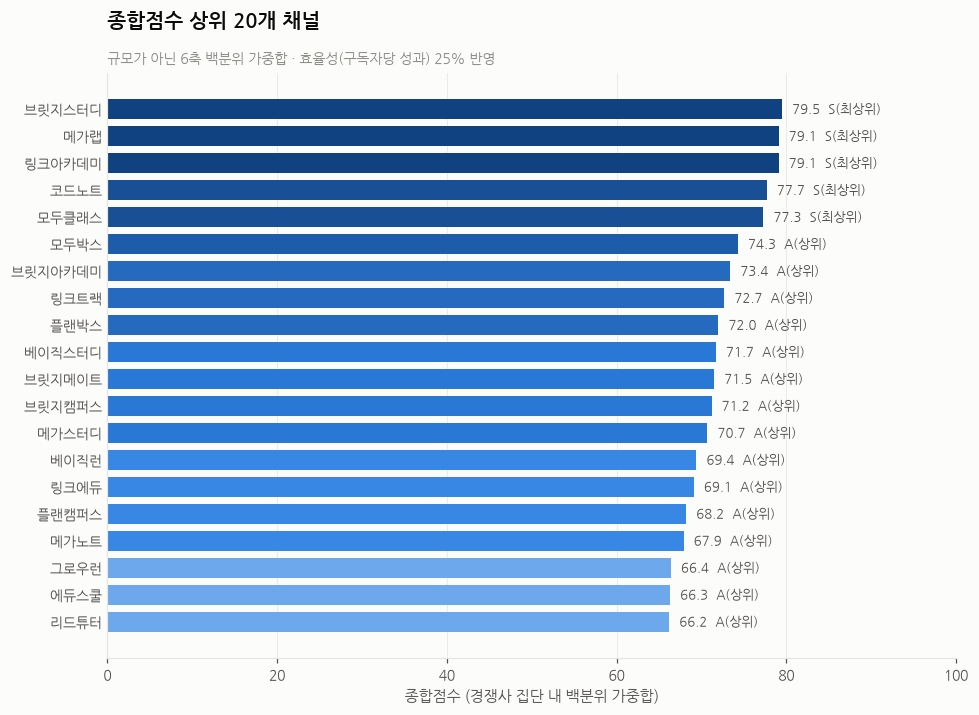

,업계순위,company_name,등급,종합점수,subscriber_count,median_views,engagement_rate_median,uploads_last_90d,진단
0,1,브릿지스터디,S(최상위),79.500,106003,"39,103.000",0.042,52,효율성 우위 / 콘텐츠설계 취약
1,2,메가랩,S(최상위),79.100,392644,"111,196.000",0.044,33,효율성 우위 / 일관성 취약
2,2,링크아카데미,S(최상위),79.100,301921,"80,053.000",0.043,60,최신성 우위 / 콘텐츠설계 취약
3,4,코드노트,S(최상위),77.700,344014,"81,317.000",0.043,38,도달력 우위 / 콘텐츠설계 취약
4,5,모두클래스,S(최상위),77.300,415746,"138,138.000",0.042,34,효율성 우위 / 콘텐츠설계 취약
5,6,모두박스,A(상위),74.300,32437,"7,658.000",0.042,48,효율성 우위 / 참여도 취약
6,7,브릿지아카데미,A(상위),73.400,332886,"63,845.500",0.037,52,도달력 우위 / 콘텐츠설계 취약
7,8,링크트랙,A(상위),72.700,66237,"19,230.000",0.045,43,효율성 우위 / 콘텐츠설계 취약
8,9,플랜박스,A(상위),72.000,17281,"5,569.000",0.044,54,최신성 우위 / 콘텐츠설계 취약
9,10,베이직스터디,A(상위),71.700,2693117,"550,362.000",0.046,39,도달력 우위 / 일관성 취약


In [5]:
ax = viz.plot_top_channels(scores, n=20)
plt.tight_layout(); plt.show()

cols = ["업계순위", "company_name", "등급", "종합점수", "subscriber_count",
        "median_views", "engagement_rate_median", "uploads_last_90d", "진단"]
scores[[c for c in cols if c in scores.columns]].head(15)

## 6. 6축 강·약점 비교

레이더 차트를 쓰지 않습니다. 축 순서에 따라 면적이 달라져 실제보다 강해/약해 보이고,
축 간 값 비교도 어렵기 때문입니다. 그룹 막대가 정확합니다.

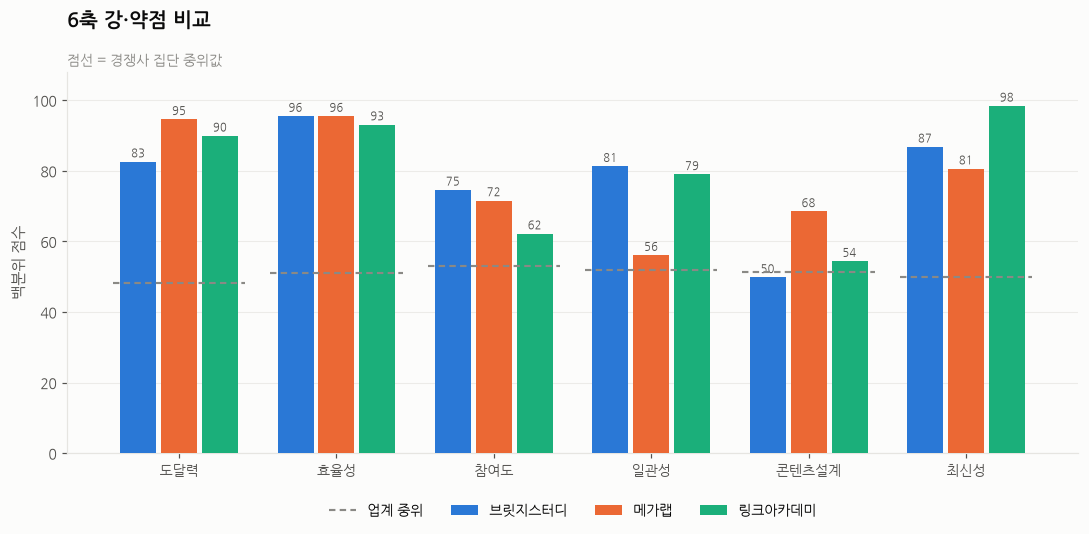

In [6]:
ax = viz.plot_axis_comparison(scores)          # 기본: 상위 3개 채널
plt.tight_layout(); plt.show()

# 특정 회사를 지정해 비교하려면:
# ax = viz.plot_axis_comparison(scores, companies=["회사A", "회사B", "회사C"])

## 7. 검증된 성공 패턴

**이 노트북의 핵심 산출물입니다.** "제목에 숫자를 넣어라" 같은 통념이 아니라,
수집된 전체 영상에서 실제 리프트를 계산한 결과입니다.

리프트 = (패턴 적용 영상의 **채널내 상대조회수** 중위) ÷ (미적용 영상의 중위)

채널 내부 상대값으로 계산한 이유: 대형 채널이 많이 쓰는 패턴이 좋아 보이는
편향을 제거하기 위함입니다.

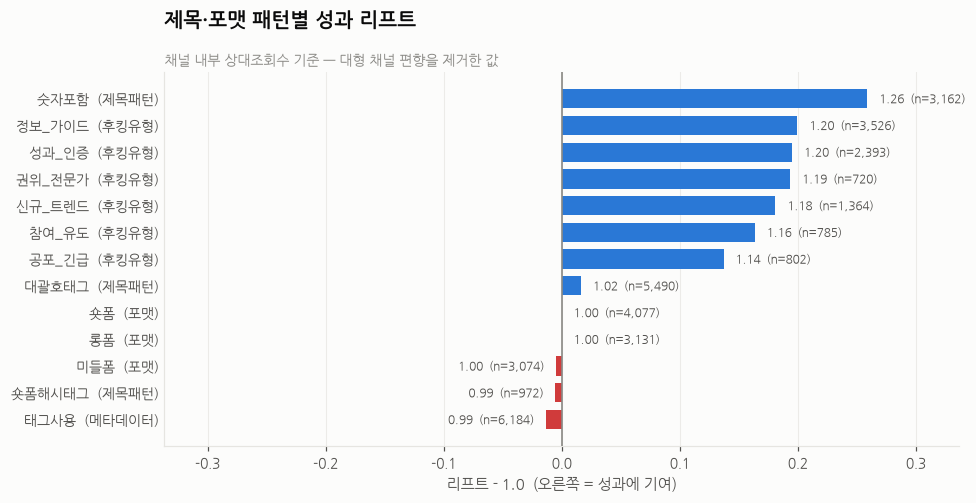

성과에 기여하는 패턴 (7개): 숫자포함, 정보_가이드, 성과_인증, 권위_전문가, 신규_트렌드, 참여_유도, 공포_긴급


,구분,패턴,사용영상수,사용률,패턴적용_상대조회수중위,미적용_상대조회수중위,리프트
0,제목패턴,숫자포함,3162,0.307,1.184,0.940,1.259
1,후킹유형,정보_가이드,3526,0.343,1.134,0.945,1.200
2,후킹유형,성과_인증,2393,0.233,1.160,0.971,1.195
3,후킹유형,권위_전문가,720,0.070,1.190,0.997,1.194
4,후킹유형,신규_트렌드,1364,0.133,1.165,0.986,1.181
5,후킹유형,참여_유도,785,0.076,1.159,0.997,1.164
6,후킹유형,공포_긴급,802,0.078,1.134,0.997,1.137
7,제목패턴,대괄호태그,5490,0.534,1.008,0.991,1.016
8,포맷,숏폼,4077,0.397,1.000,1.000,1.000
9,포맷,롱폼,3131,0.304,1.000,1.000,1.000


In [7]:
ax = viz.plot_pattern_lift(lift)
plt.tight_layout(); plt.show()

if not lift.empty:
    winners = score.winning_patterns(lift)
    print(f"성과에 기여하는 패턴 ({len(winners)}개): {', '.join(winners)}")
    display(lift)

## 8. 업로드 타이밍

두 장을 나란히 봅니다. 건수가 몰리는 시간대와 성과가 좋은 시간대가 **다르면**
그 격차가 곧 기회입니다(경쟁이 적은데 성과는 좋은 슬롯).

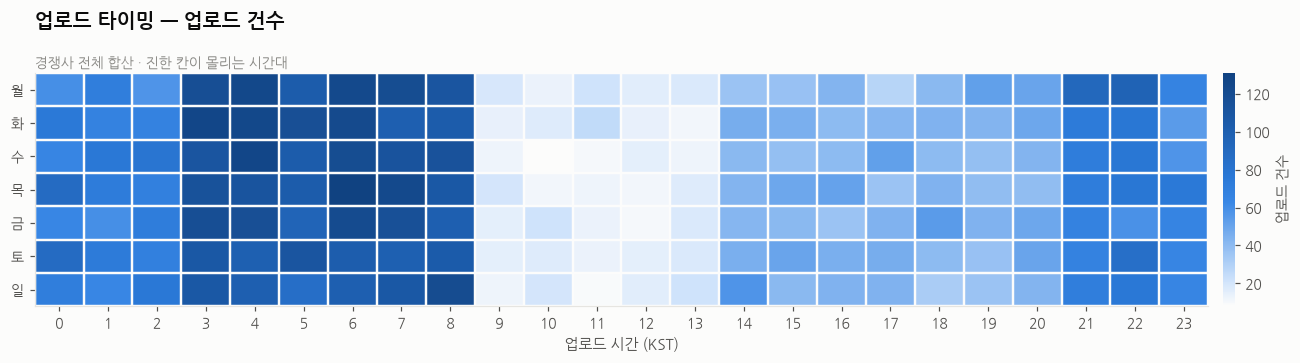

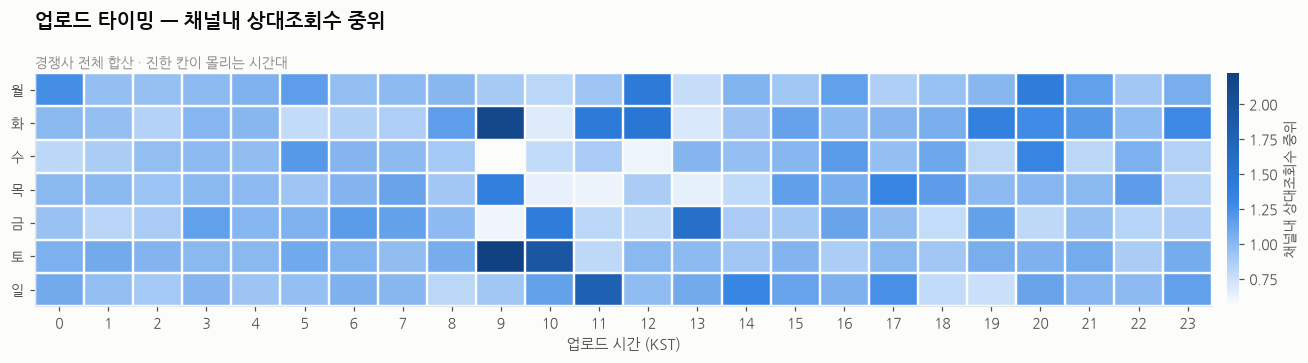

In [8]:
for metric in ("count", "median"):
    ax = viz.plot_timing_heatmap(video_features, metric=metric)
    plt.tight_layout(); plt.show()

## 9. 규모 vs 참여율

왼쪽 위(구독자는 적은데 참여율이 높은) 채널이 벤치마킹 1순위입니다.
규모로 이긴 채널보다 **콘텐츠로 이긴 채널**이 우리가 따라할 수 있는 대상입니다.

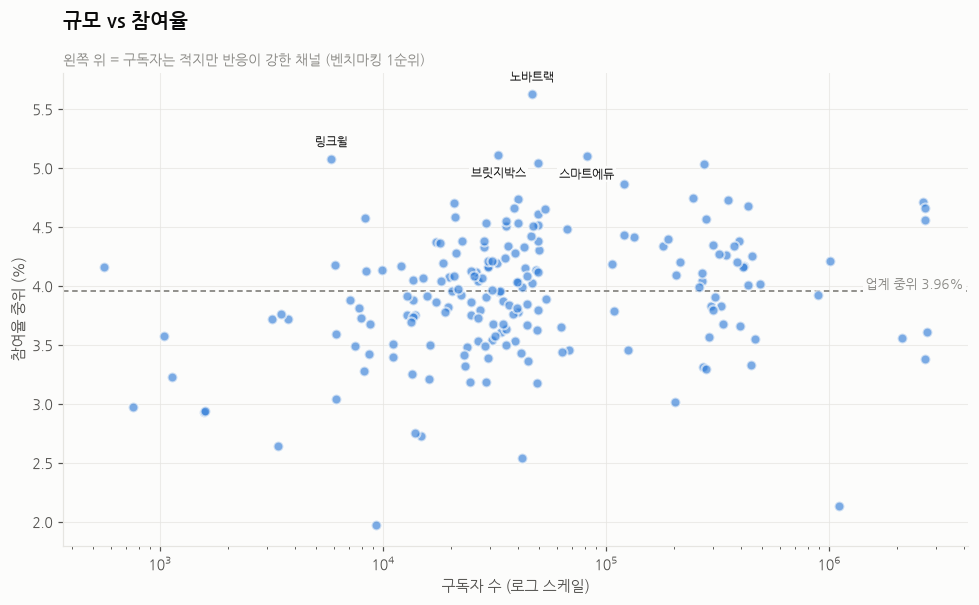

작지만 강한 채널 12개 (구독자 35,510명 이하 & 참여율 4.26% 이상)


,company_name,subscriber_count,engagement_rate_median,median_views,uploads_last_90d,종합점수
127,브릿지박스,32800,0.051,"1,917.500",7,44.100
55,링크윌,5836,0.051,"1,447.500",34,58.300
98,메가런,20775,0.047,"4,461.000",0,49.400
50,클래스캠퍼스,20841,0.046,"2,856.000",51,59.400
43,퀀텀에듀,8310,0.046,"2,710.000",50,60.400
154,테크트랙,28859,0.045,"5,004.500",0,38.200
60,브릿지노트,22445,0.044,"5,087.500",11,56.400
74,베이직클래스,28208,0.044,"6,308.000",7,54.200
8,플랜박스,17281,0.044,"5,569.000",54,72.000
171,메가윌,18024,0.044,"1,522.000",0,33.400


In [9]:
ax = viz.plot_efficiency_scatter(scores)
plt.tight_layout(); plt.show()

# 구독자 중위 이하 & 참여율 상위 25% = '작지만 강한' 채널
sub_median = scores["subscriber_count"].median()
eng_p75 = scores["engagement_rate_median"].quantile(0.75)
gems = scores[(scores["subscriber_count"] <= sub_median)
              & (scores["engagement_rate_median"] >= eng_p75)]
print(f"작지만 강한 채널 {len(gems)}개 (구독자 {sub_median:,.0f}명 이하 & 참여율 {eng_p75:.2%} 이상)")
gems[["company_name", "subscriber_count", "engagement_rate_median",
      "median_views", "uploads_last_90d", "종합점수"]].sort_values(
      "engagement_rate_median", ascending=False).head(10)

## 10. 포맷별 성과 — 숏폼을 해야 하나?

채널 중위 조회수 대비 배수로 비교합니다. 절대 조회수로 비교하면 숏폼이
항상 유리해 보이는 착시가 생깁니다.

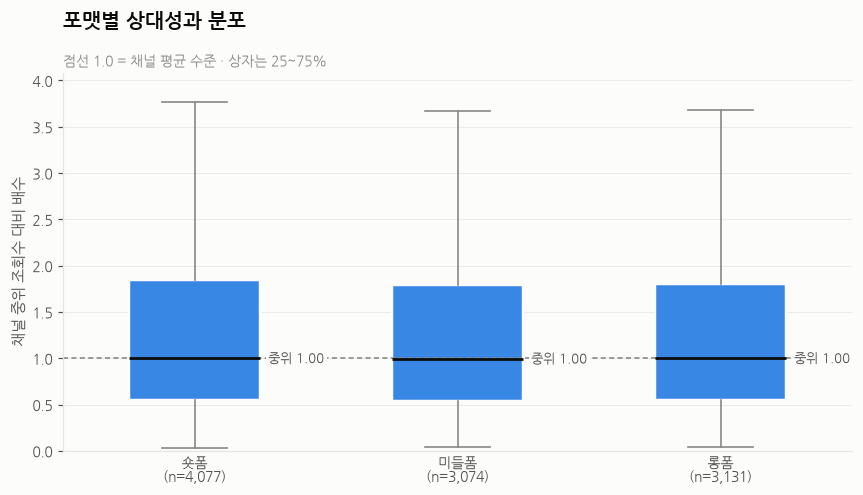

,영상수,조회수_중위,상대성과_중위,참여율_중위
format,,,,
롱폼,3131,"4,826.000",1.000,0.038
숏폼,4077,"4,885.000",1.000,0.040
미들폼,3074,"4,679.000",0.995,0.040


In [10]:
ax = viz.plot_format_performance(video_features)
plt.tight_layout(); plt.show()

fmt = (video_features.groupby("format", observed=True)
       .agg(영상수=("video_id", "count"),
            조회수_중위=("view_count", "median"),
            상대성과_중위=("views_vs_channel_median", "median"),
            참여율_중위=("engagement_rate", "median"))
       .sort_values("상대성과_중위", ascending=False))
fmt

## 11. 세그먼트 비교

`companies.csv` 의 `category` 컬럼을 채웠을 때만 의미가 있습니다.
같은 세그먼트 안에서의 순위가 전체 순위보다 실무에 더 유용합니다.

In [11]:
seg = scores.copy()
seg["category"] = seg["category"].replace("", np.nan).fillna("미분류")
summary = (seg.groupby("category", observed=True)
           .agg(채널수=("company_name", "count"),
                종합점수_평균=("종합점수", "mean"),
                구독자_중위=("subscriber_count", "median"),
                중위조회수_중위=("median_views", "median"),
                참여율_중위=("engagement_rate_median", "median"),
                업로드90일_중위=("uploads_last_90d", "median"),
                숏폼비율_평균=("숏폼_비율", "mean"))
           .sort_values("종합점수_평균", ascending=False))
summary

,채널수,종합점수_평균,구독자_중위,중위조회수_중위,참여율_중위,업로드90일_중위,숏폼비율_평균
category,,,,,,,
코딩교육,32,52.044,"40,755.000","5,134.750",0.040,9.500,0.390
학원/오프라인,17,51.812,"28,859.000","2,371.000",0.040,30.000,0.400
자격증/취업,23,50.426,"33,159.000","6,308.000",0.039,8.000,0.375
학습솔루션/SaaS,28,50.411,"37,758.000","5,671.500",0.041,7.000,0.398
성인교육/클래스,17,50.300,"36,344.000","7,801.000",0.038,7.000,0.336
유아/초등,25,49.720,"34,447.000","2,965.000",0.039,8.000,0.355
어학,29,48.679,"26,476.000","4,027.000",0.039,7.000,0.356
입시/인강,22,48.214,"39,986.000","3,754.000",0.039,7.500,0.370


## 12. 우리 채널 진단

아래 값을 우리 채널 실제 수치로 바꾸면, 193개 경쟁사 집단 내 백분위가 나옵니다.

In [12]:
# ↓ 우리 채널 실제 수치로 교체하세요
OUR_CHANNEL = {
    "구독자수": 12_000,
    "영상당_중위조회수": 3_500,
    "참여율": 0.021,            # (좋아요+댓글) / 조회수
    "최근90일_업로드수": 12,
    "숏폼비율": 0.20,
}

def percentile_of(series: pd.Series, value: float) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float((s < value).mean() * 100) if len(s) else float("nan")

diagnosis = pd.DataFrame([
    ("구독자수", OUR_CHANNEL["구독자수"], percentile_of(scores["subscriber_count"], OUR_CHANNEL["구독자수"])),
    ("영상당 중위조회수", OUR_CHANNEL["영상당_중위조회수"], percentile_of(scores["median_views"], OUR_CHANNEL["영상당_중위조회수"])),
    ("참여율", OUR_CHANNEL["참여율"], percentile_of(scores["engagement_rate_median"], OUR_CHANNEL["참여율"])),
    ("90일 업로드수", OUR_CHANNEL["최근90일_업로드수"], percentile_of(scores["uploads_last_90d"], OUR_CHANNEL["최근90일_업로드수"])),
    ("숏폼 비율", OUR_CHANNEL["숏폼비율"], percentile_of(scores["숏폼_비율"], OUR_CHANNEL["숏폼비율"])),
], columns=["지표", "우리 값", "업계 백분위"])
diagnosis["판정"] = pd.cut(diagnosis["업계 백분위"], bins=[-1, 25, 50, 75, 101],
                          labels=["하위 25% — 최우선 개선", "평균 이하", "평균 이상", "상위 25% — 강점"])
diagnosis

,지표,우리 값,업계 백분위,판정
0,구독자수,"12,000.000",13.990,하위 25% — 최우선 개선
1,영상당 중위조회수,"3,500.000",43.005,평균 이하
2,참여율,0.021,0.518,하위 25% — 최우선 개선
3,90일 업로드수,12.000,65.285,평균 이상
4,숏폼 비율,0.200,4.145,하위 25% — 최우선 개선


## 13. LLM 정성 인사이트

`python -m ytbench llm` 을 실행했다면 채널별 '배울 점 / 부족한 점'이 채워집니다.

In [13]:
insights = llm.load_insights()
if not insights:
    print("LLM 인사이트가 없습니다.")
    print("  1) ANTHROPIC_API_KEY 환경변수 설정")
    print("  2) python -m ytbench estimate     # 비용 확인")
    print("  3) python -m ytbench llm --max-channels 20 --sync   # 상위 20개 시험 실행")
else:
    print(f"인사이트 {len(insights)}건 로드")
    target = scores.iloc[0]["company_name"]
    data = insights.get(target)
    if data and "_error" not in data:
        print(f"\n=== {target} ===")
        print(f"포지셔닝: {data['positioning']}")
        print(f"성공공식: {data['content_formula']}")
        print(f"위협도  : {data['threat_level']}")
        for label, key, extra in [("배울 점", "learnings", "applicability"),
                                  ("부족한 점", "gaps", "opportunity"),
                                  ("실행안", "actions", "effort")]:
            print(f"\n[{label}]")
            for item in data.get(key, []):
                head = item.get("point") or item.get("action", "")
                print(f"  · {head}")
                print(f"    근거: {item.get('evidence', item.get('rationale', ''))}")
                print(f"    {extra}: {item.get(extra, '')}")

    display(llm.insights_to_frame(insights).head())

LLM 인사이트가 없습니다.
  1) ANTHROPIC_API_KEY 환경변수 설정
  2) python -m ytbench estimate     # 비용 확인
  3) python -m ytbench llm --max-channels 20 --sync   # 상위 20개 시험 실행


## 14. 엑셀 리포트 생성

지금까지의 분석을 10시트 엑셀로 내보냅니다.

In [14]:
insights_df = llm.insights_to_frame(llm.load_insights())
resolved_df = (pd.read_csv(config.RESOLVED_CSV, encoding="utf-8-sig")
               if config.RESOLVED_CSV.exists() else None)

path = report.build_report(
    scores, channel_metrics, video_features, industry, lift,
    insights_df=insights_df, resolved=resolved_df,
)
print(f"생성 완료: {path}  ({path.stat().st_size / 1024:,.0f} KB)")

생성 완료: /home/user/Study/edutech_youtube_benchmark/output/에듀테크_경쟁사_유튜브_벤치마킹.xlsx  (180 KB)


## 다음 단계

1. **`08_매칭검수` 시트를 먼저 확인** — 오매칭 1건이 그 채널의 모든 수치를 오염시킵니다.
   맞는 채널 URL을 `data/companies.csv` 에 채우고 `python -m ytbench resolve` 재실행.
2. **7번 섹션의 검증된 패턴**을 우리 콘텐츠 제작 가이드에 반영.
3. **9번 섹션의 '작지만 강한 채널'** 을 우선 벤치마킹 대상으로 선정.
4. **8번 섹션에서 경쟁이 적고 성과가 좋은 업로드 슬롯**을 찾아 편성에 반영.
5. 주간 갱신: `python -m ytbench collect --no-resume && python -m ytbench analyze && python -m ytbench report`
   (쿼터 약 800 units, 무료 한도의 8%)